In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv(
    "../datasets/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt",
    sep='@',
    header=None,
    names=["Sentence", "Sentiment"],
    encoding="latin-1",
    engine="python"
)

print("Dataset Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nFirst 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

Dataset Shape: (2264, 2)

Data Types:

Sentence     str
Sentiment    str
dtype: object

First 5 Rows


,Sentence,Sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive



Last 5 Rows


,Sentence,Sentiment
2259,Operating result for the 12-month period decre...,negative
2260,HELSINKI Thomson Financial - Shares in Cargote...,negative
2261,LONDON MarketWatch -- Share prices ended lower...,negative
2262,Operating profit fell to EUR 35.4 mn from EUR ...,negative
2263,Sales in Finland decreased by 10.5 % in Januar...,negative


In [4]:
print("Input Feature:")
print(df.columns[0])

print("\nTarget Column:")
print(df.columns[1])

Input Feature:
Sentence

Target Column:
Sentiment


In [5]:
print("Unique Labels:")
print(df["Sentiment"].unique())

print("\nNumber of Classes:", df["Sentiment"].nunique())

Unique Labels:
<ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Number of Classes: 3


### Observation:

Positive
Negative
Neutral

Hence:

Multi-class Classification

In [10]:
missing = df.isnull().sum()
print(missing)

Sentence     0
Sentiment    0
dtype: int64


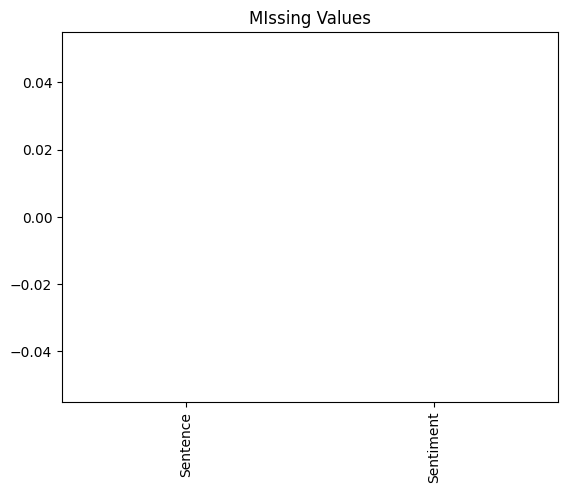

In [14]:
missing.plot(kind = "bar")
plt.title("MIssing Values")
plt.show()

In [15]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

duplicate_sentences = df[df.duplicated()]

duplicate_sentences.head()

Duplicate Rows: 5


,Sentence,Sentiment
519,The issuer is solely responsible for the conte...,neutral
626,The report profiles 614 companies including ma...,neutral
929,Ahlstrom 's share is quoted on the NASDAQ OMX ...,neutral
1027,SSH Communications Security Corporation is hea...,neutral
1409,The company serves customers in various indust...,neutral


In [18]:
class_counts = df["Sentiment"].value_counts()
print(class_counts)
print(round(class_counts/len(df) * 100,2))

Sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
Sentiment
neutral     61.44
positive    25.18
negative    13.38
Name: count, dtype: float64


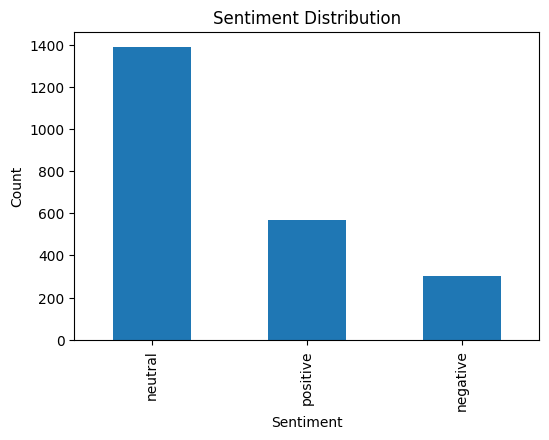

In [19]:
class_counts.plot(
    kind = "bar",
    figsize = (6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [20]:
df["Sentence_Length"] = df["Sentence"].apply(lambda x: len(str(x).split()))

df["Sentence_Length"].describe()

count    2264.000000
mean       22.441696
std        10.147048
min         2.000000
25%        15.000000
50%        21.000000
75%        28.000000
max        81.000000
Name: Sentence_Length, dtype: float64

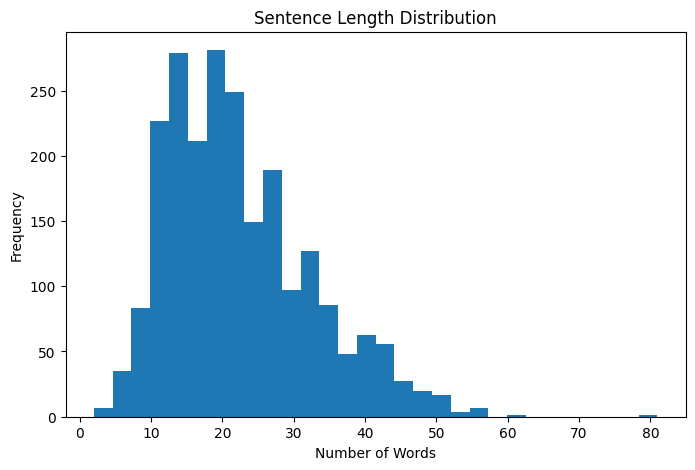

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Sentence_Length"], bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [24]:
datasets = {
    "50Agree":"../datasets/FinancialPhraseBank-v1.0/Sentences_50Agree.txt",
    "66Agree":"../datasets/FinancialPhraseBank-v1.0/Sentences_66Agree.txt",
    "75Agree":"../datasets/FinancialPhraseBank-v1.0/Sentences_75Agree.txt",
    "AllAgree":"../datasets/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"
}

summary=[]

for name,path in datasets.items():

    temp=pd.read_csv(
        path,
        sep='@',
        header=None,
        names=["Sentence","Sentiment"],
        encoding="latin-1",
        engine="python"
    )

    summary.append([name,temp.shape[0]])

summary_df=pd.DataFrame(
    summary,
    columns=["Dataset","Rows"]
)

summary_df

,Dataset,Rows
0,50Agree,4846
1,66Agree,4217
2,75Agree,3453
3,AllAgree,2264


We selected Sentences_AllAgree because it contains the highest-quality sentiment labels, with 100% agreement among annotators. Although it has fewer samples than the other versions, the reduced label noise makes it more suitable for generating reliable financial sentiment features. Since our project uses a pretrained FinBERT model and the primary predictive model is trained on the much larger FI-2010 dataset, the smaller size of the AllAgree subset is not expected to be a significant limitation.

 ### Observation:

No lowercasing
No stop-word removal
No stemming
No lemmatization

Only:

FinBERT tokenizer

In [25]:
print(df.head())

                                            Sentence Sentiment  \
0  According to Gran , the company has no plans t...   neutral   
1  For the last quarter of 2010 , Componenta 's n...  positive   
2  In the third quarter of 2010 , net sales incre...  positive   
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive   
4  Operating profit totalled EUR 21.1 mn , up fro...  positive   

   Sentence_Length  
0               25  
1               39  
2               29  
3               24  
4               22  


In [26]:
print("Skewness of Sentence Length")

print(df["Sentence_Length"].skew())

Skewness of Sentence Length
0.8436453989868621


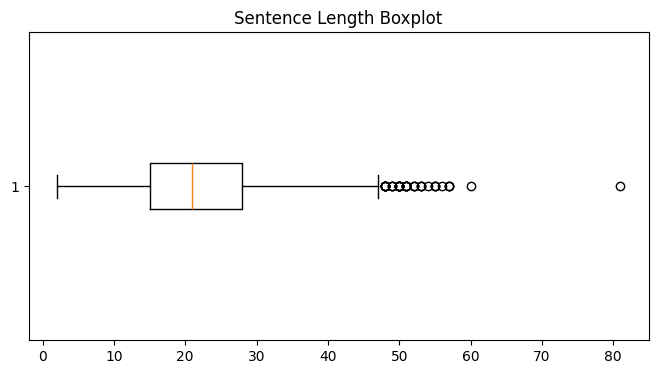

In [27]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Sentence_Length"],vert=False)

plt.title("Sentence Length Boxplot")

plt.show()

In [28]:
Q1=df["Sentence_Length"].quantile(0.25)

Q3=df["Sentence_Length"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[
    (df["Sentence_Length"]<lower)|
    (df["Sentence_Length"]>upper)
]

print("Number of Outliers:",len(outliers))

outliers.head()

Number of Outliers: 40


,Sentence,Sentiment,Sentence_Length
8,Foundries division reports its sales increased...,positive,50
11,MegaFon 's subscriber base increased 16.1 % in...,positive,50
33,The world 's second largest stainless steel ma...,positive,48
37,At the request of Finnish media company Alma M...,neutral,50
114,"EUR928 ,000 in Q1 2010 6 May 2010 - Finnish te...",positive,48


In [30]:
print("Financial PhraseBank EDA Summary")

print(f"Dataset Shape: {df.shape}")

print(f"Missing Values: {df.isnull().sum().sum()}")

print(f"Duplicate Rows: {df.duplicated().sum()}")

print(f"Number of Classes: {df['Sentiment'].nunique()}")

print("\nClass Distribution:")

print(df["Sentiment"].value_counts())

print("\nAverage Sentence Length:")

print(round(df["Sentence_Length"].mean(),2),"words")

print("\nSentence Length Skewness:")

print(round(df["Sentence_Length"].skew(),2))

Financial PhraseBank EDA Summary
Dataset Shape: (2264, 3)
Missing Values: 0
Duplicate Rows: 5
Number of Classes: 3

Class Distribution:
Sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Average Sentence Length:
22.44 words

Sentence Length Skewness:
0.84


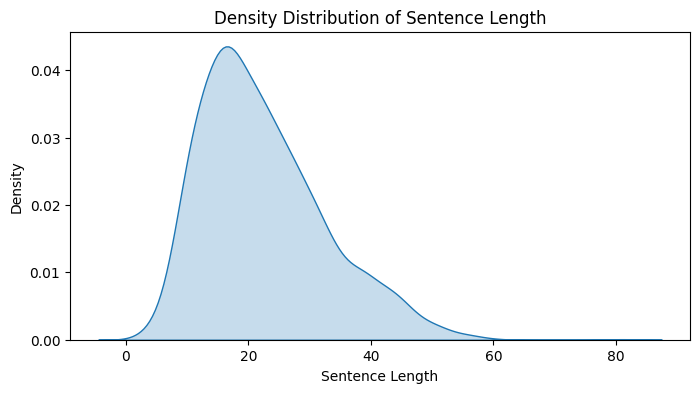

In [31]:
plt.figure(figsize=(8,4))
sns.kdeplot(df["Sentence_Length"], fill=True)

plt.title("Density Distribution of Sentence Length")
plt.xlabel("Sentence Length")
plt.show()

In [32]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print("Constant Columns:", constant_cols)

Constant Columns: []


|  Column          | Description                                |
| --------------- | ------------------------------------------ |
| Sentence        | Financial news headline or sentence        |
| Sentiment       | Target label (Positive, Neutral, Negative) |
| Sentence_Length | Number of words in the sentence            |


Dataset contains financial news sentences with sentiment labels.
No missing values were found.
Duplicate sentences were checked.
This is a multi-class classification problem.
Sentence lengths are moderately right-skewed, with a few long-sentence outliers.
Sentences_AllAgree was selected because it has the highest annotation quality.
The dataset is suitable for FinBERT as it consists of labeled financial text.